In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
## Loading the dataset
df = pd.read_csv("Online Retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print(f"The dataset consist of {df.shape[0]} rows and {df.shape[1]} columns")

The dataset consist of 541909 rows and 8 columns


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
## Checking null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.shape

(406829, 8)

In [9]:
## Descriptive summarty 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,406829.0,12.061303,248.693370,-80995.0,2.00,5.00,12.00,80995.0
UnitPrice,406829.0,3.460471,69.315162,0.0,1.25,1.95,3.75,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.0,13953.00,15152.00,16791.00,18287.0


In [10]:
df.describe(include ='object')


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,406829,406829,406829,406829,406829
unique,22190,3684,3896,20460,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,11/14/2011 15:27,United Kingdom
freq,542,2077,2070,543,361878


In [11]:
df.duplicated().sum()

np.int64(5225)

In [12]:
## Dropping the duplicate rows
df.drop_duplicates(inplace = True)

In [13]:
print(f"the dataset consist of {df.shape[0]} rows and {df.shape[1]} columns after removing duplicates")


the dataset consist of 401604 rows and 8 columns after removing duplicates


In [14]:
## Handeling cancelled transactions
filtered_df = df[df['InvoiceNo'].str.startswith("C")]
print(f"total number of cancelled transactions {filtered_df.shape[0]}")

total number of cancelled transactions 8872


In [15]:
df['Transaction_Status'] = df['InvoiceNo'].astype(str).apply(lambda x: 'Cancelled' if x.startswith('C') else 'Completed')

In [16]:
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancelled_transactions.describe()

,Quantity,UnitPrice,CustomerID
count,8872.000000,8872.000000,8872.000000
mean,-30.774910,18.899512,14990.152953
std,1172.249902,445.190864,1708.230387
min,-80995.000000,0.010000,12346.000000
25%,-6.000000,1.450000,13505.000000
50%,-2.000000,2.950000,14868.000000
75%,-1.000000,4.950000,16393.000000
max,-1.000000,38970.000000,18282.000000


* all the quantities of cancelled transactions are -ve.
* unit price shows a variety of range from low to high.

In [17]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed


In [18]:
## Correcting StockCode Anomalies
unique_stockcode = df['StockCode'].nunique()
unique_stockcode

3684

Text(0.5, 1.0, 'Top 10 stock codes')

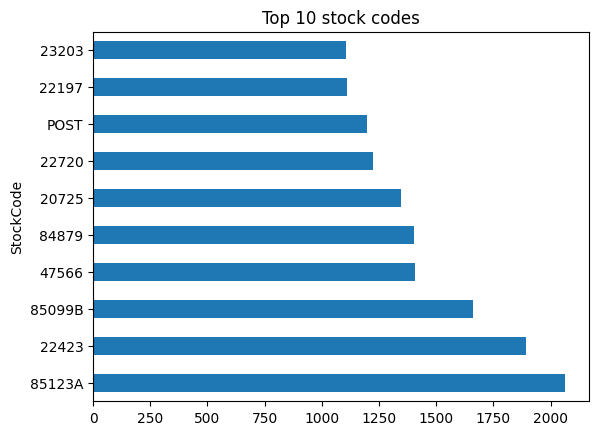

In [19]:
## Top 10 most frequent stockcodes
top_10_stock = df['StockCode'].value_counts().head(10).plot(kind = 'barh')
plt.title('Top 10 stock codes')

* from this we can say most of the stock codes composed of 5 or 6 cahracters.
* there are anomalies like : "POST"

In [20]:
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

print("Value counts of numeric characters in unique stock codes")
print(numeric_char_counts_in_unique_codes)

Value counts of numeric characters in unique stock codes
5    3676
0       7
1       1
Name: count, dtype: int64


In [21]:
## removing all the anomalies stock code

anomalous_stock_code =  [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

df = df[~df['StockCode'].isin(anomalous_stock_code)]

In [22]:
df.shape

(399689, 9)

In [23]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed


Text(0.5, 1.0, 'Top 30 Descriptions')

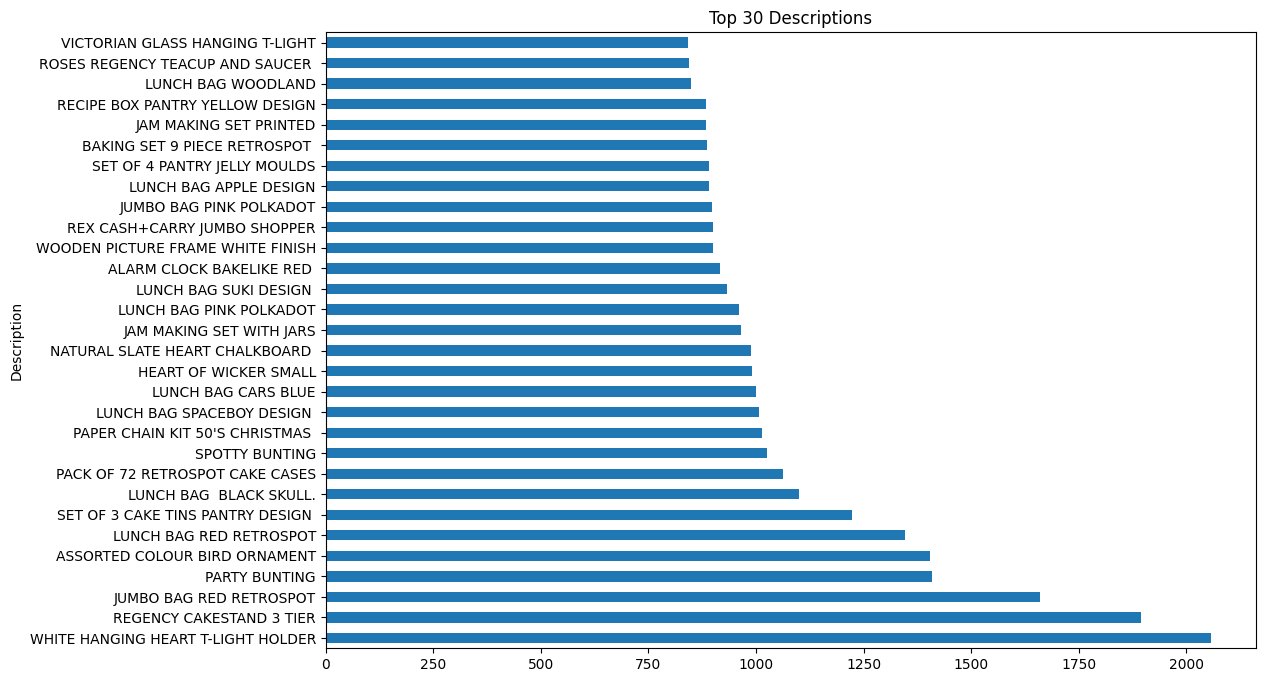

In [24]:
# Handeling Description Feature

# Top 30 Descriptions 
columnstop_30_descriptions = df['Description'].value_counts().head(30).plot(kind = 'barh',figsize=(12, 8))
plt.title("Top 30 Descriptions")


* Most of the items are household items like jars , lunch bags, ornaments and more.
* Most of them are in uppercase letters but some some are not so need to correct it and make standard format.


In [25]:
lowercase_desc = df['Description'].unique()
lowercase_desc = [desc for desc in lowercase_desc if any(char.islower() for char in desc)]
for desc in lowercase_desc:
    print(desc)

BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


* some items are not product descriptions like "Next Day Carriage", "High Resolution Image"

In [26]:
print("Total number of anomalies:")
len(lowercase_desc)

Total number of anomalies:


19

* Removing the non products
* Converting remaining from lower to upper case

In [27]:
not_procduct_desc = ["Next Day Carriage", "High Resolution Image"]
df = df[~df['Description'].isin(not_procduct_desc)]

df['description'] = df['Description'].str.upper()

In [28]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status,description
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,Completed,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,Completed,WHITE METAL LANTERN


In [29]:
# Hindling Unit price feature
Zero_unit = df[df['UnitPrice']== 0]

In [30]:
Zero_unit.shape

(33, 10)

33 data contains unit price as 0

In [31]:
df = df[df['UnitPrice'] > 0]

In [32]:
df.shape

(399573, 10)

In [33]:
# Resetting the indes of the cleaned dataset
df.reset_index(drop = True, inplace = True)

# Feature Engineering


RFM Features
* R - Recency -> How recently customer made a purchase. low recency means the customer purchased most recently.
* F -Frequency -> how oftern customer makes a purchase within a certain period. High Frequency means a customer makes purchases very often.
* M - Monetary ->  How much money a customer spends. high monetary means customer contributed more in business.

In [34]:
# Recency 

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extracting date
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Finding the most recent purchase date for each customer
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

most_recent_date = df['InvoiceDay'].max()

# Convert InvoiceData and most_recent_date to datetime
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

## Calculating receny - last day since last purchase
customer_data['Day_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Removing invoice day 
customer_data.drop('InvoiceDay', axis = 1, inplace = True)

In [35]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


Customer_data is a centric data which contains all the details about the customers

In [36]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Transaction_Status,description,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Completed,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Completed,WHITE METAL LANTERN,2010-12-01


In [37]:
## Frequency

## Creating two columns Total Transactions and Total Products purchased

total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns = {'InvoiceNo': 'Total_Transactions'}, inplace = True)

In [38]:
total_transactions.head()

,CustomerID,Total_Transactions
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [39]:
# Total products purchased by customers
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns = {'Quantity': 'Total_Products_Purchased'}, inplace = True)

In [40]:
total_products_purchased.head()

,CustomerID,Total_Products_Purchased
0,12346.0,0
1,12347.0,2458
2,12348.0,2332
3,12349.0,630
4,12350.0,196


In [41]:
## Merging both new features to customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on = 'CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on = 'CustomerID')


In [42]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


In [43]:
# Monetary

# Total amount spent by each customer
df['Total_Spend'] = df['Quantity'] * df['UnitPrice']

total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

In [44]:
total_spend.head()

,CustomerID,Total_Spend
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1437.24
3,12349.0,1457.55
4,12350.0,294.40


In [45]:
## Average transaction value for each customers

total_spend = total_spend.merge(total_transactions, on = 'CustomerID')

total_spend['Average_Transaction_Value'] = total_spend['Total_Spend'] / total_spend['Total_Transactions']



In [46]:
total_spend.head()

,CustomerID,Total_Spend,Total_Transactions,Average_Transaction_Value
0,12346.0,0.00,2,0.000000
1,12347.0,4310.00,7,615.714286
2,12348.0,1437.24,4,359.310000
3,12349.0,1457.55,1,1457.550000
4,12350.0,294.40,1,294.400000


In [47]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


In [48]:
## Merging total_spend to customer_data

customer_data = pd.merge(customer_data, total_spend[['CustomerID','Total_Spend','Average_Transaction_Value']], on = 'CustomerID')

In [49]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


# Checking Product Diversity


* Represents distict products bought by a customer. higher value shows customer has a diverse taste or preference.

In [50]:
# Unique prodcut purchased

unique_product_purchased = df.groupby('CustomerID')['StockCode'].nunique().reset_index()

unique_product_purchased.rename(columns = {'StockCode': 'Unique_Products_Purchased'}, inplace = True)

In [51]:
unique_product_purchased.head()

,CustomerID,Unique_Products_Purchased
0,12346.0,1
1,12347.0,103
2,12348.0,21
3,12349.0,72
4,12350.0,16


In [52]:
## Merge new features into the customer_data dataframe

customer_data = pd.merge(customer_data, unique_product_purchased, on = 'CustomerID')

In [53]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,0,0.00,0.000000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16


# Behavioural Features

understanding the shopping pattern and behavious of customers.

* Average days b/w purchases: Avg. no of within customer purchases.

* Favrouite Shopping Day : Day of week customer shops the most.

* Favrouite Shopping Hour : Hours of the day. when customer shops the most


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399573 entries, 0 to 399572
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           399573 non-null  object        
 1   StockCode           399573 non-null  object        
 2   Description         399573 non-null  object        
 3   Quantity            399573 non-null  int64         
 4   InvoiceDate         399573 non-null  datetime64[ns]
 5   UnitPrice           399573 non-null  float64       
 6   CustomerID          399573 non-null  float64       
 7   Country             399573 non-null  object        
 8   Transaction_Status  399573 non-null  object        
 9   description         399573 non-null  object        
 10  InvoiceDay          399573 non-null  object        
 11  Total_Spend         399573 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 36.6+ MB


In [55]:
# Average days between purchases

# Extract day of week and hour from invoice date
df['Day_Of_Week'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Convert 'InvoiceDay' to datetime if not already
df['InvoiceDay'] = pd.to_datetime(df['InvoiceDay'])

# Calculate days between consecutive purchases
df['Days_Between_Purchases'] = df.groupby('CustomerID')['InvoiceDay'].diff().dt.days

# Calculate the average days between purchases per customer
average_days_between_purchases = df.groupby('CustomerID')['Days_Between_Purchases'].mean().reset_index()

# Rename column
average_days_between_purchases.rename(columns={'Days_Between_Purchases': 'Average_Days_Between_Purchases'}, inplace=True)


In [56]:
average_days_between_purchases.head()

,CustomerID,Average_Days_Between_Purchases
0,12346.0,0.000000
1,12347.0,2.016575
2,12348.0,10.884615
3,12349.0,0.000000
4,12350.0,0.000000


In [57]:
# Favrouite Shopping day of week

favroite_shopping_day = df.groupby(['CustomerID','Day_Of_Week']).size().reset_index(name = 'Count')

favorite_shopping_day = favroite_shopping_day.loc[favroite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]



In [58]:
favorite_shopping_day.head()

,CustomerID,Day_Of_Week
0,12346.0,1
2,12347.0,1
6,12348.0,3
8,12349.0,0
9,12350.0,2


In [59]:
# Find the favorite shopping hour of the day
favorite_shopping_hour = df.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]


In [60]:
favorite_shopping_hour.head()

,CustomerID,Hour
0,12346.0,10
5,12347.0,14
9,12348.0,19
10,12349.0,9
11,12350.0,16


In [61]:
## Merging the features into customer_data

customer_data = pd.merge(customer_data, average_days_between_purchases, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='CustomerID')


In [62]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16


# Geographical Features

In [63]:
df['Country'].value_counts(normalize = True).head()

Country
United Kingdom    0.890971
Germany           0.022722
France            0.020402
EIRE              0.018440
Spain             0.006162
Name: proportion, dtype: float64

Most of the transactions originating from the United Kingdom, so we might create a feature which indicates that transaction is from UK or Not.

In [64]:
customer_country = df.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')

# Get the country with the maximum number of transactions for each customer (in case a customer has transactions from multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('CustomerID')

# Create a binary column indicating whether the customer is from the UK or not
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)


In [65]:
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'Is_UK']], on='CustomerID', how='left')


In [66]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0
3,12349.0,18,1,630,1457.55,1457.550000,72,0.000000,0,9,0
4,12350.0,310,1,196,294.40,294.400000,16,0.000000,2,16,0


# Cancellation Insight

In [67]:
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancellation_frequency = cancelled_transactions.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

cancellation_frequency.rename(columns = {'InvoiceNo': 'Cancellation_Frequency'}, inplace = True)

In [68]:
# Merging 
customer_data = pd.merge(customer_data, cancellation_frequency, on = 'CustomerID')


In [69]:
customer_data.head(2)

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency
0,12346.0,325,2,0,0.00,0.00000,1,0.00000,1,10,1,1
1,12352.0,36,8,463,1265.41,158.17625,57,3.13253,1,14,0,1


In [70]:
## Replacing null values with 0
customer_data.fillna(0, inplace = True)

In [71]:
# Cancellation rate
customer_data['Cancellation_Rate'] = customer_data['Cancellation_Frequency'] / total_transactions['InvoiceNo']

In [72]:
customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1,0.500000
1,12352.0,36,8,463,1265.41,158.176250,57,3.132530,1,14,0,1,0.142857
2,12359.0,7,6,1599,6182.98,1030.496667,214,1.296000,3,12,0,2,0.500000
3,12362.0,3,13,2180,4665.58,358.890769,200,1.110266,3,15,0,3,3.000000
4,12375.0,2,3,175,375.42,125.140000,13,6.400000,4,14,0,1,1.000000


# Outlier Detection and Correction


In [73]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination = 0.05)

customer_data['Outlier'] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())

customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier']]

customer_data.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Outlier,Is_Outlier
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1,0.500000,1,0
1,12352.0,36,8,463,1265.41,158.176250,57,3.132530,1,14,0,1,0.142857,1,0
2,12359.0,7,6,1599,6182.98,1030.496667,214,1.296000,3,12,0,2,0.500000,1,0
3,12362.0,3,13,2180,4665.58,358.890769,200,1.110266,3,15,0,3,3.000000,1,0
4,12375.0,2,3,175,375.42,125.140000,13,6.400000,4,14,0,1,1.000000,1,0


In [74]:
# percentage of outlier and inlier

outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize = True) * 100

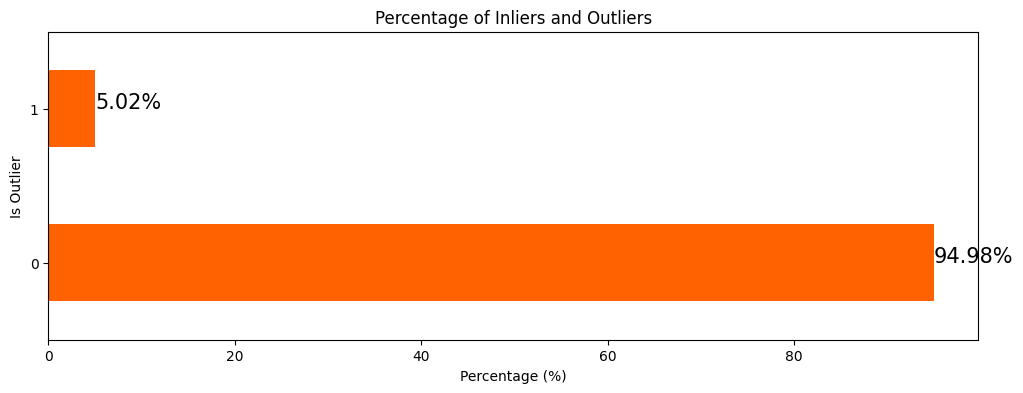

In [75]:
# Plotting the percentage of inliers and outliers
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh', color='#ff6200')

# Adding the percentage labels on the bars
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%', fontsize=15)

plt.title('Percentage of Inliers and Outliers')

plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.show()

5 % of customers have been identified as outlier in our curated dataset.


In [76]:
customer_data.shape

(1534, 15)

In [77]:
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]

customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]

customer_data_cleaned.drop(columns = ['Outlier', 'Is_Outlier'],inplace = True)

customer_data_cleaned.reset_index(drop = True, inplace = True)


C:\Users\princ\AppData\Local\Temp\ipykernel_22088\1266879650.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_data_cleaned.drop(columns = ['Outlier', 'Is_Outlier'],inplace = True)


In [78]:
customer_data_cleaned.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1,0.500000
1,12352.0,36,8,463,1265.41,158.176250,57,3.132530,1,14,0,1,0.142857
2,12359.0,7,6,1599,6182.98,1030.496667,214,1.296000,3,12,0,2,0.500000
3,12362.0,3,13,2180,4665.58,358.890769,200,1.110266,3,15,0,3,3.000000
4,12375.0,2,3,175,375.42,125.140000,13,6.400000,4,14,0,1,1.000000


In [79]:
customer_data_cleaned.shape

(1457, 13)

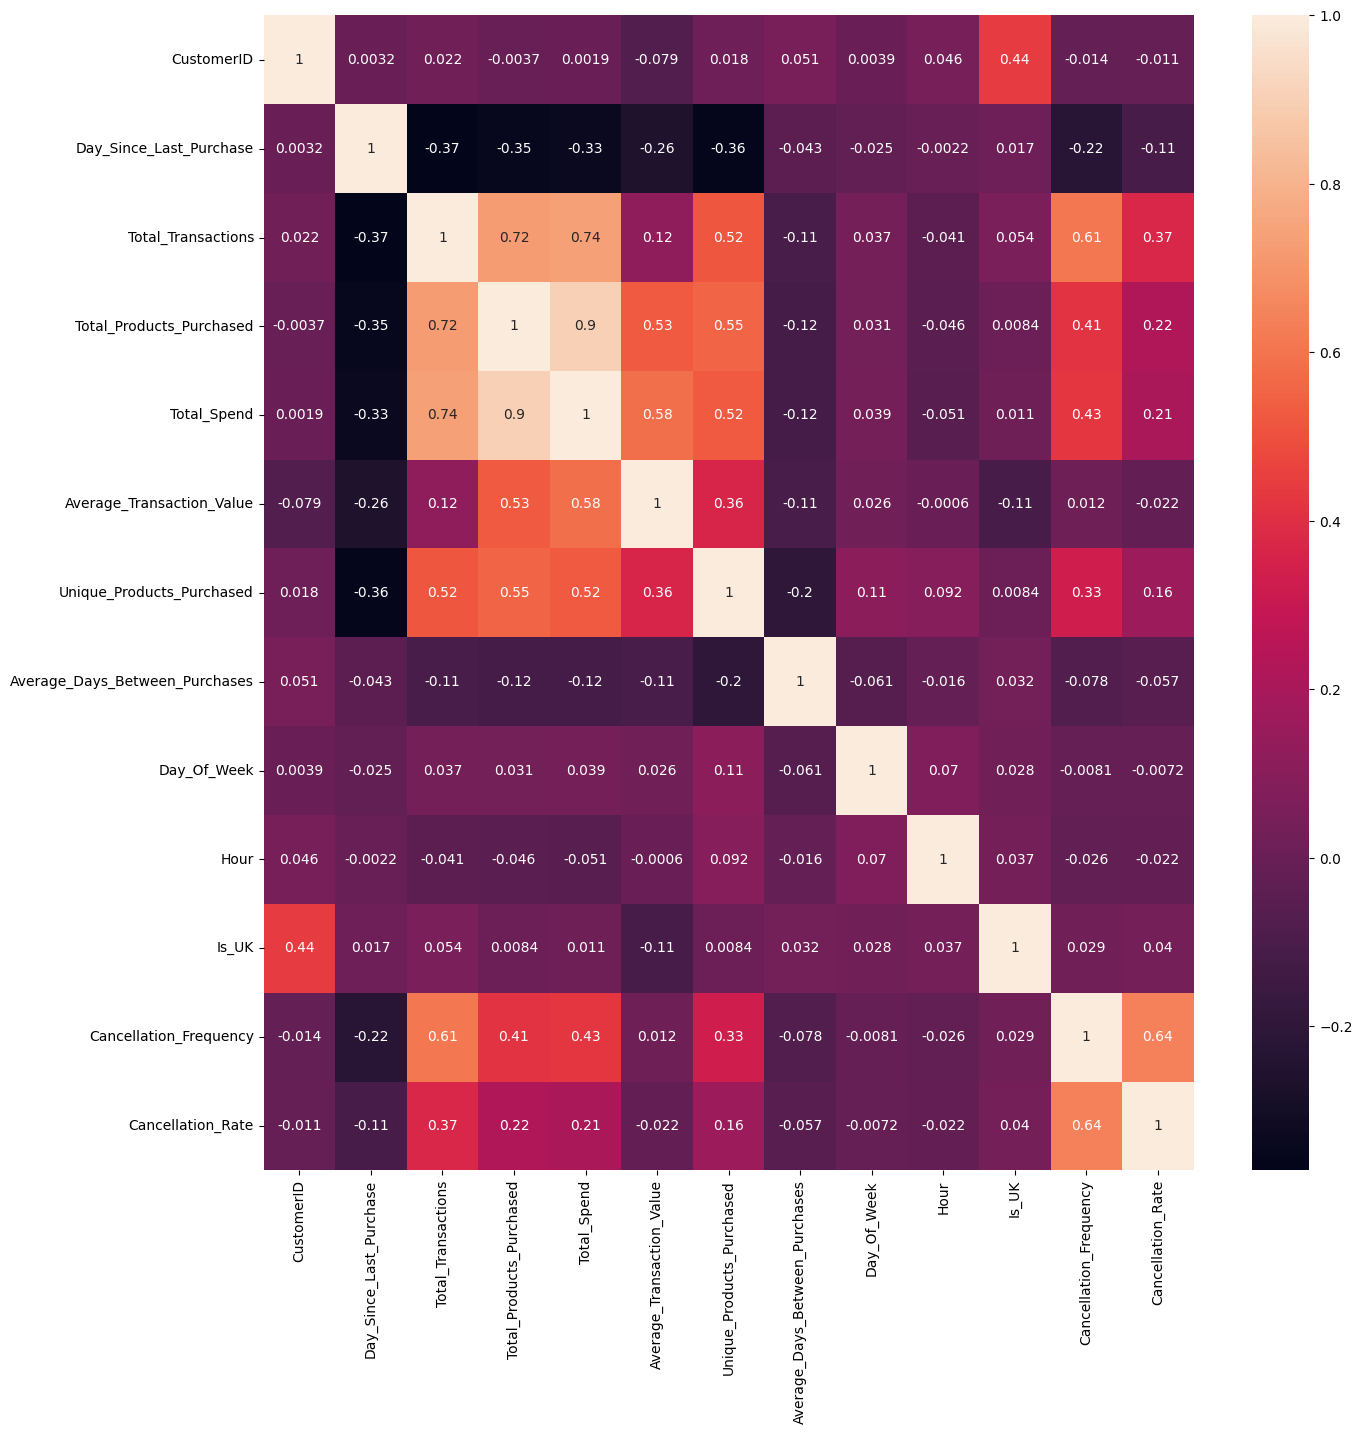

In [80]:
plt.figure(figsize=(15,15))
sns.heatmap(customer_data_cleaned.corr(),annot=True)
plt.show()

# Feature Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# exclude columns
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']

columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

customer_data_scaled = customer_data_cleaned.copy()

customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_cleaned[columns_to_scale])

In [82]:
customer_data_scaled.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,2.957573,-0.860004,-0.882752,-0.855957,-1.301274,-1.041207,-0.378643,1,-1.040120,1,-0.586321,-0.379074
1,12352.0,-0.337389,0.016340,-0.558101,-0.358586,-0.493922,-0.332482,-0.044782,1,0.710333,0,-0.586321,-0.698112
2,12359.0,-0.668026,-0.275775,0.238451,1.574270,3.958512,1.654480,-0.240517,3,-0.164893,0,0.066291,-0.379074
3,12362.0,-0.713631,0.746627,0.645843,0.977854,0.530551,1.477298,-0.260312,3,1.147947,0,0.718904,1.854194
4,12375.0,-0.725032,-0.713947,-0.760044,-0.708398,-0.662543,-0.889338,0.303461,4,0.710333,0,-0.586321,0.067580


# Dimensionality Reduction

In [83]:
from sklearn.decomposition import PCA
# Setting CustomerID as the index column
customer_data_scaled.set_index('CustomerID', inplace=True)


In [84]:
# Creating a PCA object with 6 components
pca = PCA(n_components=6)

customer_data_pca = pca.fit_transform(customer_data_scaled)

# labelling columns as PC1, PC2, etc.
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Adding the CustomerID 
customer_data_pca.index = customer_data_scaled.index

In [85]:
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerID,,,,,,
12346.0,-3.059107,-0.922031,0.741980,-0.607848,-1.917566,1.279887
12352.0,-1.172516,-1.159339,-0.406104,-0.365418,0.746444,-0.513119
12359.0,2.505393,0.189362,-2.927300,-0.050797,-0.240704,0.386567
12362.0,2.601432,0.103468,0.673405,-0.833208,1.038430,0.059108
12375.0,-1.138441,1.810854,0.302926,0.236896,0.917674,-0.549365


In [86]:
# Define the top 3 absolute values in each column of a dataframe
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color:  grey' if i in top3 else '' for i in column.index]

# Create the PCA component DataFrame and apply the highlighting function
pc_df = pd.DataFrame(pca.components_.T, columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],
                     index=customer_data_scaled.columns)

pc_df.style.apply(highlight_top3, axis=0)

,PC1,PC2,PC3,PC4,PC5,PC6
Day_Since_Last_Purchase,-0.247903,0.048608,0.114007,-0.287518,-0.352118,0.753095
Total_Transactions,0.414782,-0.092244,0.182746,0.052823,0.009923,-0.022231
Total_Products_Purchased,0.437528,-0.095829,-0.169583,0.055116,-0.069555,0.220552
Total_Spend,0.440665,-0.092491,-0.183519,0.063604,-0.085471,0.262421
Average_Transaction_Value,0.251210,-0.041330,-0.522550,0.004820,-0.064005,0.246291
Unique_Products_Purchased,0.355063,-0.014670,-0.135703,-0.197980,0.123038,-0.239629
Average_Days_Between_Purchases,-0.099065,-0.026129,0.046583,0.757663,0.469853,0.355277
Day_Of_Week,0.199120,0.973949,0.055185,0.077080,-0.035130,0.021871
Hour,-0.004312,0.064637,-0.044488,-0.533591,0.788600,0.230407
Is_UK,0.001863,0.003986,0.021380,0.000633,0.013640,0.005777


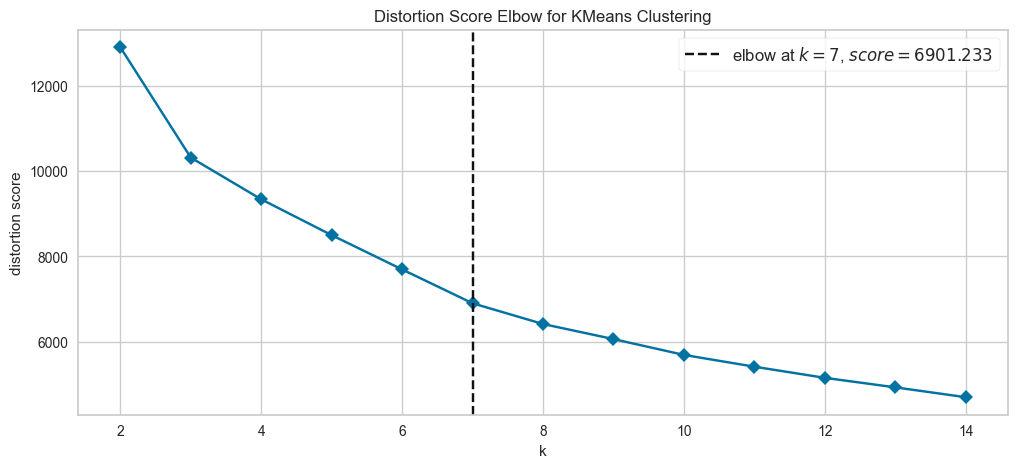

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [87]:
# Determining optimal number of clusters using elboe method

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer


# Instantiate the clustering model with the specified parameters
km = KMeans(init='k-means++', n_init=10, max_iter=100, random_state=0)

fig, ax = plt.subplots(figsize=(12, 5))

# Instantiate the KElbowVisualizer with the model and range of k values, and disable the timing plot
visualizer = KElbowVisualizer(km, k=(2, 15), timings=False, ax=ax)

visualizer.fit(customer_data_pca)

visualizer.show()

In [88]:
# Apply KMeans clustering using the optimal k

from collections import Counter

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)

# Get the frequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)

# Create a mapping from old labels to new labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in
                 enumerate(cluster_frequencies.most_common())}

# Reverse the mapping to assign labels as per your criteria
label_mapping = {v: k for k, v in {2: 1, 1: 0, 0: 2}.items()}

# Apply the mapping to get the new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# Append the new cluster labels back to the original dataset
customer_data_cleaned['cluster'] = new_labels

# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels

C:\Users\princ\AppData\Local\Temp\ipykernel_22088\928580942.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_data_cleaned['cluster'] = new_labels


In [89]:
customer_data_cleaned.head()

,CustomerID,Day_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,cluster
0,12346.0,325,2,0,0.00,0.000000,1,0.000000,1,10,1,1,0.500000,0
1,12352.0,36,8,463,1265.41,158.176250,57,3.132530,1,14,0,1,0.142857,0
2,12359.0,7,6,1599,6182.98,1030.496667,214,1.296000,3,12,0,2,0.500000,1
3,12362.0,3,13,2180,4665.58,358.890769,200,1.110266,3,15,0,3,3.000000,1
4,12375.0,2,3,175,375.42,125.140000,13,6.400000,4,14,0,1,1.000000,2


In [90]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Compute number of customers
from tabulate import tabulate
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)


# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],

]

# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+---------------------+
|         Metric          |        Value        |
+-------------------------+---------------------+
| Number of Observations  |        1457         |
|    Silhouette Score     | 0.23543456595602189 |
| Calinski Harabasz Score |  445.8497413901519  |
+-------------------------+---------------------+


*   Silhouette score of approx 0.236, not close to 1 still shows a fair amount of seperation.
*   Calinski Harabasz Score is 454.42 which is high, shows that clusters are well-defined.

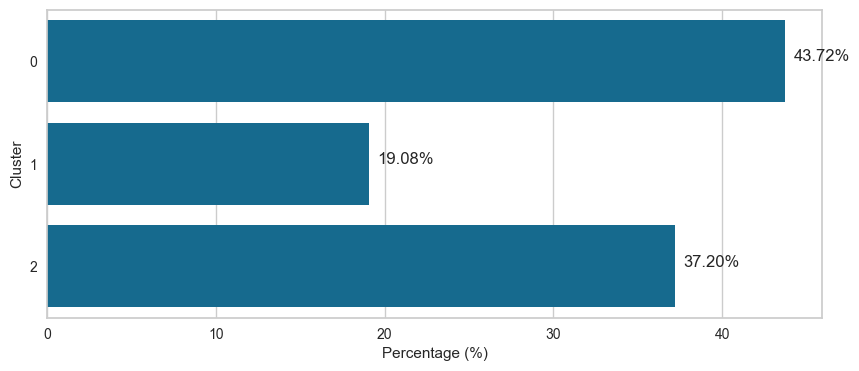

In [91]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h')

# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.xlabel('Percentage (%)')

# Show the plot
plt.show()

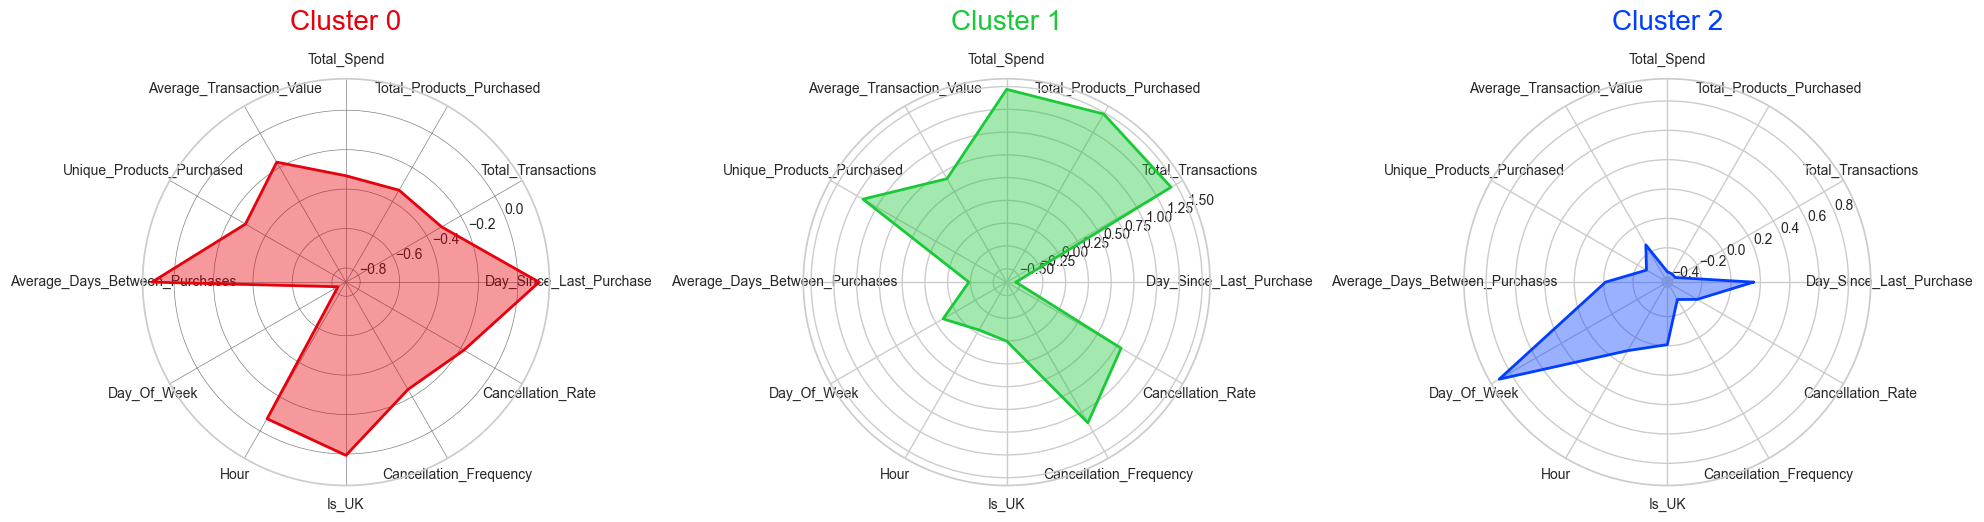

In [92]:
colors = ['#e8000b', '#1ac938', '#023eff']
# Setting 'CustomerID' column as index and assigning it to a new dataframe
df_customer = customer_data_cleaned.set_index('CustomerID')

# Standardize the data (excluding the cluster column)
scaler = StandardScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['cluster'], axis=1))

# Create a new dataframe with standardized values and add the cluster column back
df_customer_standardized = pd.DataFrame(df_customer_standardized, columns=df_customer.columns[:-1], index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['cluster']

# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    
    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels=np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data = cluster_centroids.loc[i].tolist()
    data += data[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data, color, i)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()